In [2]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

cancer_dir = '/kaggle/input/oralcancer-jpg/OralCancer-JPG/cancer-jpg'
non_cancer_dir = '/kaggle/input/oralcancer-jpg/OralCancer-JPG/non-cancer-jpg'

def load_image_paths_and_labels(cancer_dir, non_cancer_dir):
    cancer_images = [os.path.join(cancer_dir, img) for img in os.listdir(cancer_dir) if img.endswith(('.jpg','.jpeg','.png'))]
    non_cancer_images = [os.path.join(non_cancer_dir, img) for img in os.listdir(non_cancer_dir) if img.endswith(('.jpg','.jpeg','.png'))]

    image_paths = np.array(cancer_images + non_cancer_images)
    labels = np.array([1]*len(cancer_images) + [0]*len(non_cancer_images))

    return image_paths, labels

image_paths, labels = load_image_paths_and_labels(cancer_dir, non_cancer_dir)

train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42
)

def preprocess_image(image_path, img_size=(244,244)):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=1)
    image = tf.image.resize(image, img_size)

    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)

    image = image / 255.0
    return image

def create_dataset(image_paths, labels, batch_size=32):

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    def load_and_preprocess(path, label):
        image = preprocess_image(path)
        return image, label

    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

train_dataset = create_dataset(train_paths, train_labels)
test_dataset = create_dataset(test_paths, test_labels)

In [3]:
class GraphConvLayer(tf.keras.layers.Layer):
    def __init__(self, output_dim):
        super(GraphConvLayer, self).__init__()
        self.output_dim = output_dim

    def build(self, input_shape):
        self.kernel = self.add_weight(
            shape=(input_shape[-1], self.output_dim),
            initializer='random_normal',
            trainable=True
        )

    def call(self, inputs, adjacency_matrix):
        output = tf.matmul(adjacency_matrix, inputs)
        output = tf.matmul(output, self.kernel)
        return output


class GSONNModel(tf.keras.Model):
    def __init__(self, input_shape, adjacency_matrix):
        super(GSONNModel, self).__init__()

        self.cnn_layer = tf.keras.Sequential([
            tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=input_shape),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.MaxPooling2D((2,2)),

            tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.MaxPooling2D((2,2)),

            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(128,activation='relu',
            kernel_regularizer=tf.keras.regularizers.l2(0.01)),

            tf.keras.layers.Dropout(0.2)
        ])

        self.graph_conv = GraphConvLayer(64)
        self.output_layer = tf.keras.layers.Dense(1,activation='sigmoid')
        self.adjacency_matrix = adjacency_matrix

    def call(self, inputs):
        cnn_output = self.cnn_layer(inputs)

        cnn_output = tf.expand_dims(cnn_output,axis=1)
        cnn_output = tf.tile(cnn_output,[1,self.adjacency_matrix.shape[0],1])

        gcn_output = self.graph_conv(cnn_output,self.adjacency_matrix)
        gcn_output = tf.reduce_mean(gcn_output,axis=1)

        return self.output_layer(gcn_output)

Epoch 1/90
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.5811 - loss: 3.5202 - val_accuracy: 0.6667 - val_loss: 1.3700 - learning_rate: 0.0010
Epoch 2/90
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.6978 - loss: 1.1794 - val_accuracy: 0.6667 - val_loss: 0.8643 - learning_rate: 0.0010
Epoch 3/90
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.7089 - loss: 0.7699 - val_accuracy: 0.7401 - val_loss: 0.6706 - learning_rate: 0.0010
Epoch 4/90
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.7511 - loss: 0.6759 - val_accuracy: 0.7345 - val_loss: 0.6324 - learning_rate: 0.0010
Epoch 5/90
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.7501 - loss: 0.6328 - val_accuracy: 0.7232 - val_loss: 0.6376 - learning_rate: 0.0010
Epoch 6/90
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.7583 - loss: 0.6066 - val_accuracy: 0.7684 - val_loss: 0.5698 - learning_rate: 0.0010
Epoch 7/90
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.7855 - loss: 0.5661 - val_ac

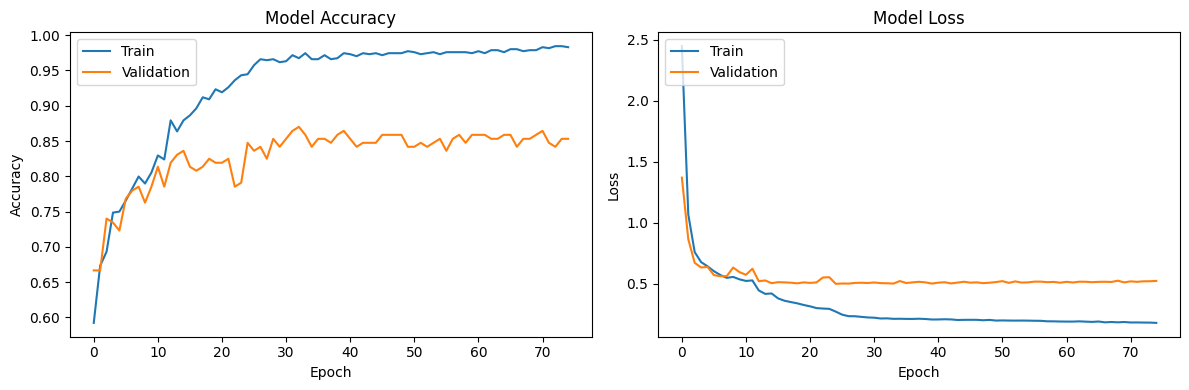

In [33]:
def create_graph(num_images):
    adjacency_matrix = np.random.rand(num_images, num_images)
    adjacency_matrix = adjacency_matrix / adjacency_matrix.sum(axis=1, keepdims=True)
    return adjacency_matrix

adjacency_matrix = create_graph(len(train_paths))
adjacency_matrix_tensor = tf.convert_to_tensor(adjacency_matrix, dtype=tf.float32)

input_shape = (244,244,1)

model = GSONNModel(input_shape, adjacency_matrix_tensor)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)
]

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=90,
    callbacks=callbacks
)

test_loss, test_acc = model.evaluate(test_dataset)

print("Test Accuracy:", test_acc)


def plot_history(history):

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train','Validation'], loc='upper left')

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train','Validation'], loc='upper left')

    plt.tight_layout()
    plt.show()


plot_history(history)


In [5]:
!pip install google-generativeai==0.7.2

/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [28]:
import google.generativeai as genai

genai.configure(api_key="API KEY")
llm_model = genai.GenerativeModel("gemini-flash-latest")



In [29]:
for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-2.5-flash-lite-preview-09-2025
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-robotics-er-1.5-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-pro-preview-12-2025


In [30]:
def generate_llm_explanation(prediction, confidence):

    label = "Oral Cancer Detected" if prediction == 1 else "No Oral Cancer Detected"

    prompt = f"""
    A deep learning system analyzed an oral cavity image.

    Prediction: {label}
    Confidence score: {confidence}

    Explain the result in simple medical language
    and suggest possible next medical steps.
    """

    response = llm_model.generate_content(prompt)

    return response.text

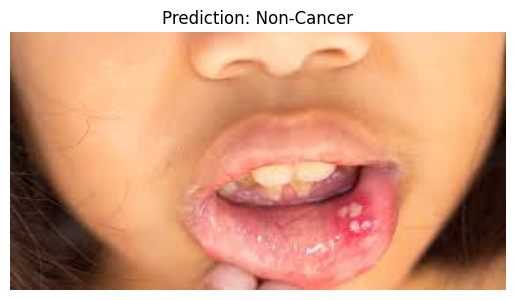

Confidence: 0.3614274263381958

LLM Medical Explanation:
This result should be interpreted with caution. While the AI system’s primary prediction is "No Oral Cancer Detected," the **Confidence Score** is the most important part of this report.

### 1. Explanation of the Result

*   **The Prediction:** The AI looked at the image and did not find strong enough visual patterns to label it as "Cancer."
*   **The Confidence Score (0.36 or 36%):** In medical AI, a confidence score ranges from 0 to 1 (or 0% to 100%). A score of **0.36 is very low.** 
    *   Usually, for a result to be considered reliable, the confidence score should be very high (typically above 0.90 or 90%).
    *   A score of 36% suggests the AI is **uncertain**. It means the system struggled to distinguish between healthy tissue and a potential abnormality. It is effectively "unsure" of its own "No Cancer" prediction.

**In short:** The AI is leaning toward "No Cancer," but it is not confident enough for this to be consid

In [35]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image_path = "/kaggle/input/testing-images/Testing_Images/download (2).jfif"

# preprocess image
image = preprocess_image(image_path)
image = tf.expand_dims(image, axis=0)

# model prediction
output = model(image)

threshold = 0.5

predicted_class = 1 if output.numpy()[0,0] > threshold else 0
confidence = float(output.numpy()[0,0])

# LLM explanation
explanation = generate_llm_explanation(predicted_class, confidence)

# display image
image_display = mpimg.imread(image_path)

plt.imshow(image_display)
plt.axis('off')
plt.title(f"Prediction: {'Cancer' if predicted_class == 1 else 'Non-Cancer'}", fontsize=12)
plt.show()

print("Confidence:", confidence)
print("\nLLM Medical Explanation:")
print(explanation)